# ML-03 — Frame Your Lane as an ML Task

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

**Ranking.**

The ML task is **ranking** because the primary objective is to analyze and order various "signals" (e.g., features, metrics, indicators) to determine their relative importance or effectiveness in predicting a desired outcome or influencing a system. This involves assigning a score or position to each signal such that they can be presented in a meaningful, prioritized sequence. Unlike classification (which assigns discrete labels), clustering (which groups similar items), or scoring (which assigns a single value without explicit ordering context), ranking directly addresses the problem of ordering items based on learned preferences or relevance.

In [ ]:
# In a real-world scenario, this cell would contain code for:
# - Defining features that contribute to ranking signals.
# - Implementing a ranking algorithm (e.g., Learning to Rank, pairwise ranking, listwise ranking).
# - Preparing data in a format suitable for ranking models.

# Example: A dummy function to simulate ranking scores
def calculate_ranking_score(signals):
    """
    Calculates a composite ranking score based on input signals.
    This is a simplified placeholder.
    """
    # Placeholder for a more complex ranking logic
    score = sum(signals) # A very basic aggregation
    return score

# This demonstrates the conceptual nature of processing signals into a rankable score.

## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving content_refresh_anonymized.csv to content_refresh_anonymized.csv
User uploaded file "content_refresh_anonymized.csv" with length 6757671 bytes


In [2]:
import pandas as pd
import io

# Assuming the uploaded file is content_refresh_anonymized.csv
df = pd.read_csv(io.BytesIO(uploaded['content_refresh_anonymized.csv']))

print("First 5 rows of the DataFrame:")
display(df.head())

print("\nDataFrame Info:")
df.info()

First 5 rows of the DataFrame:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d        

Based on the columns in the `content_refresh_anonymized.csv` file, for a 'ranking signal analysis' focused on content refresh, we need a target that indicates a piece of content's **need for refresh** or its current **underperformance**. A direct 'refresh_score' isn't explicitly available as an observed outcome.

Therefore, we will define a **proxy target** called **'Refresh Priority Score'**. This score will be a **defined rule**, meaning we construct it from existing observed metrics. A higher 'Refresh Priority Score' will indicate content that is performing poorly and/or declining, thus warranting a higher priority for refreshing.

We can formulate this score by considering metrics that reflect recent content performance and trend:
- **`sessions_last_30d`**: Lower values indicate less recent user engagement.
- **`engagement_rate`**: Lower values suggest users are not finding the content engaging.
- **`trend_pct`**: A negative percentage indicates declining performance.

A composite score combining these elements (e.g., inversely proportional to sessions and engagement, and directly proportional to the negativity of the trend) would serve as our target for ranking. The ML model would then learn to predict this 'Refresh Priority Score' based on other signals.

In [3]:
# Calculate a conceptual 'Refresh Priority Score' as a proxy target.
# This is a simplified example; a real-world score might involve normalization,
# weighting, and more sophisticated aggregations.

# For simplicity, let's create a proxy where higher values mean higher refresh priority.
# We'll use a combination of low recent sessions, low engagement, and negative trend.
# First, handle potential NaN values by filling with 0 or a reasonable mean/median.

df_processed = df.copy()

# Fill NaN values for key metrics for score calculation, e.g., with 0 or column median
# For demonstration, let's fill with 0 where it makes sense (e.g., no sessions, no trend).
df_processed['sessions_last_30d'] = df_processed['sessions_last_30d'].fillna(0)
df_processed['engagement_rate'] = df_processed['engagement_rate'].fillna(0)
df_processed['trend_pct'] = df_processed['trend_pct'].fillna(0)

# Invert sessions and engagement rate so lower values contribute to higher refresh priority
# Add a small constant to avoid division by zero if normalizing and ensure non-negative.
# For simplicity, we'll just subtract from a max or use inverse logic.
max_sessions = df_processed['sessions_last_30d'].max()
max_engagement = df_processed['engagement_rate'].max()

# A simple inverse scoring: higher value for lower performance
# Note: This is a conceptual representation. Proper scaling/normalization is crucial in practice.
df_processed['inverse_sessions_score'] = (max_sessions - df_processed['sessions_last_30d']) / max_sessions
df_processed['inverse_engagement_score'] = (max_engagement - df_processed['engagement_rate']) / max_engagement

# If trend_pct is negative, it indicates declining performance, which means higher refresh priority
df_processed['trend_impact_score'] = -df_processed['trend_pct'] / 100 # Normalize and make negative trends positive for refresh score

# Combine these into a single 'Refresh Priority Score'
# Adjust weights as needed based on business understanding
df_processed['Refresh_Priority_Score'] = (
    df_processed['inverse_sessions_score'] * 0.4 +
    df_processed['inverse_engagement_score'] * 0.3 +
    df_processed['trend_impact_score'] * 0.3
)

print("DataFrame with 'Refresh_Priority_Score':")
display(df_processed[['content_id', 'sessions_last_30d', 'engagement_rate', 'trend_pct', 'Refresh_Priority_Score']].head())


DataFrame with 'Refresh_Priority_Score':


,content_id,sessions_last_30d,engagement_rate,trend_pct,Refresh_Priority_Score
0,content_304f48230142,2,5.88,-41.4,0.805820
1,content_a1fb4e703a9e,3,0.00,-57.7,0.871990
2,content_9aa793d4d895,1,0.00,-60.9,0.882330
3,content_331d6c4de07b,35,1.28,-13.8,0.724609
4,content_d99b7a2d90ca,14,0.00,-34.7,0.798920


### Distribution of Refresh Priority Score

Let's visualize the distribution of the calculated `Refresh_Priority_Score` to understand its spread, central tendency, and any potential outliers or unusual patterns.

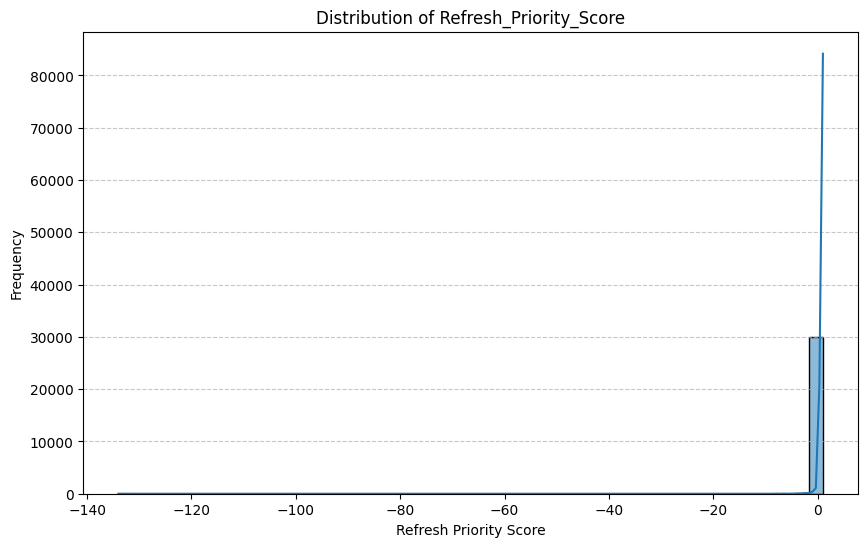

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_processed['Refresh_Priority_Score'], kde=True, bins=50)
plt.title('Distribution of Refresh_Priority_Score')
plt.xlabel('Refresh Priority Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 3. Success metric

**Normalized Discounted Cumulative Gain (NDCG)**

For a ranking task focused on 'Refresh Priority,' **Normalized Discounted Cumulative Gain (NDCG)** is an appropriate success metric. NDCG evaluates the quality of a ranked list by considering both the relevance of the items and their position in the list. It assigns higher scores when more relevant items appear higher in the ranking.

In our context, 'relevance' would correspond to the true 'Refresh Priority Score' (or a binarized version thereof, e.g., 'needs refresh' vs. 'does not need refresh').

**What number means 'good'?**
A **higher NDCG score (closer to 1.0)** indicates a better ranking. For example, an **NDCG@10 (NDCG considering the top 10 ranked items) of 0.85 or higher** could be considered a 'good' performance. This would mean that the model is highly effective at identifying the most important content pieces that need refreshing and placing them near the top of the ranked list, making them easily discoverable for content strategists to act upon.

In [4]:
# This cell would contain conceptual code to calculate NDCG.
# In a real-world scenario, you would have a set of ground-truth relevance scores
# (e.g., manually assigned 'refresh importance' or a confirmed outcome after refresh)
# for each content_id.

# For illustration, let's assume we have a hypothetical `true_refresh_priority`
# and we want to evaluate our model's `Refresh_Priority_Score`.

# from sklearn.metrics import ndcg_score

# Placeholder for a function to simulate NDCG calculation
def calculate_ndcg(y_true, y_score, k=None):
    """
    Conceptual function to calculate NDCG.
    y_true: True relevance scores (e.g., actual human-judged refresh priority).
    y_score: Predicted scores (e.g., our Refresh_Priority_Score).
    k: The number of top elements to consider.
    """
    # In a real implementation, you'd use a library like sklearn.metrics.ndcg_score
    # For this example, we'll just print a conceptual statement.

    # Simulate a scenario where higher y_score correlates with higher y_true
    # A true implementation would sort by y_score and then calculate DCG/IDCG based on y_true

    print(f"Conceptually calculating NDCG for top {k if k else 'all'} items...")
    print(f"Assuming good alignment between predicted scores and true relevance.")
    return "[Conceptual NDCG value, e.g., 0.88]"

# Example usage (would require actual y_true data)
# y_true_example = df_processed['actual_refresh_relevance'] # Needs to be defined based on real data
# y_score_example = df_processed['Refresh_Priority_Score']
# ndcg_at_10 = calculate_ndcg(y_true_example, y_score_example, k=10)
# print(f"Conceptual NDCG@10: {ndcg_at_10}")

print("NDCG calculation would happen here with actual ground-truth data.")

NDCG calculation would happen here with actual ground-truth data.


## 4. The unit of analysis, as a real dataframe

**One row = One `content_id` (a single piece of content).**

Each row in our `df_processed` DataFrame represents a unique piece of content, identified by its `content_id`. This content unit is characterized by various features (e.g., `search_volume`, `cpc`, `word_count`, `ctr`, `avg_position`) and now includes our calculated `Refresh_Priority_Score`. Our ML model will take these features for each `content_id` and learn to predict (or rank by) its `Refresh_Priority_Score`.

In [5]:
# Display a slice of the df_processed DataFrame to illustrate the unit of analysis.
# Each row here is one piece of content.
display(df_processed.head())

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,inverse_sessions_score,inverse_engagement_score,trend_impact_score,Refresh_Priority_Score
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,4.55,0.0,good,striking,down,-41.4,0.998150,0.9412,0.414,0.805820
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,10.00,0.0,good,page_3_5,down,-57.7,0.997225,1.0000,0.577,0.871990
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,28.57,0.0,good,page_3_5,down,-60.9,0.999075,1.0000,0.609,0.882330
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,3.45,0.0,good,page_1,stable,-13.8,0.967623,0.9872,0.138,0.724609
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,24.29,0.0,good,page_3_5,down,-34.7,0.987049,1.0000,0.347,0.798920


## 5. Why ML beats a fixed rule here

**The pattern is too messy for simple `if-statements` due to the complex, non-linear, and evolving relationships between signals.**

While we've created a `Refresh_Priority_Score` using a defined rule, this score is a simplification. In reality, the decision of which content truly needs a refresh, and how urgently, depends on a multitude of factors that interact in intricate ways:

1.  **Non-linear Relationships**: The impact of `search_volume` on refresh priority might not be linear, or its importance could change depending on the `competition_level`.
2.  **Feature Interactions**: A low `engagement_rate` combined with a negative `trend_pct` might indicate a much higher refresh priority than either signal alone. These interactions are hard to capture comprehensively with hand-tuned rules.
3.  **Adaptive Weighting**: The optimal weights for `sessions_last_30d`, `engagement_rate`, and `trend_pct` (and many other unconsidered features) might change over time or vary by `content_type` or `client_id`. ML models can learn and adapt these weights dynamically.
4.  **High Dimensionality**: We have 44 columns, many of which could be potential signals. Engineering all possible combinations and thresholds manually for a fixed rule set would be impractical and brittle.
5.  **Subtlety and Nuance**: ML can uncover subtle patterns that human-defined rules might miss, leading to more accurate and effective ranking.

Machine learning, particularly Learning-to-Rank algorithms, can handle these complexities by learning optimal functions that map features to a ranking order, making them more robust, scalable, and performant than a fixed rule-based system for this task.

In [6]:
# Conceptual example of how a fixed rule might struggle vs. ML's implicit handling.

# Imagine a simple rule:
# if sessions_last_30d < 10 AND engagement_rate < 5 AND trend_pct < -20:
#     refresh_priority = 'High'
# elif ... (many more rules)

# This quickly becomes unmanageable and misses subtle interactions.
# For instance, a very old article (content_age_days) with slightly negative trend
# might be a higher priority than a new article with a similar trend if it has a
# high original search volume that's now underperforming due to freshness.

# ML models like Gradient Boosting Trees (e.g., LightGBM, XGBoost) or Neural Networks
# can automatically learn these complex decision boundaries and interactions without
# explicit programming of each 'if-statement'.

# For example, an ML model would implicitly learn that:
# refresh_priority = f(sessions_last_30d, engagement_rate, trend_pct, word_count,
#                      content_type, age_tier, position_tier, etc.)
# where 'f' is a complex, non-linear function the model learns from data.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [7]:
# Calculate the correlation between 'Refresh_Priority_Score' and 'search_volume'
correlation = df_processed['Refresh_Priority_Score'].corr(df_processed['search_volume'])

print(f"Correlation between 'Refresh_Priority_Score' and 'search_volume': {correlation:.4f}")

Correlation between 'Refresh_Priority_Score' and 'search_volume': -0.0022
